In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [9]:
np.random.seed(42)

n = 200

data =pd.DataFrame({
    "experience": np.random.randint(0, 10, n),
    "education_years": np.random.randint(10, 20, n),
    "age": np.random.randint(22, 60, n),
})

data["salary"] = (
    3000 +
    data["experience"] * 4000 +
    data["education_years"] * 2000 +
    data["age"] * 500 +
    np.random.rand(n) * 10000
)

data.head()

,experience,education_years,age,salary
0,6,15,22,71945.217986
1,3,10,37,54567.560659
2,7,18,26,83356.600648
3,4,15,43,72196.799039
4,6,12,50,82468.483617


In [10]:
print(data.shape)
print(data.info())
print(data.describe())


(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       200 non-null    int64  
 1   education_years  200 non-null    int64  
 2   age              200 non-null    int64  
 3   salary           200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB
None
       experience  education_years         age         salary
count  200.000000       200.000000  200.000000     200.000000
mean     4.560000        14.325000   41.090000   75315.897435
std      2.899731         2.943245   10.903501   13605.639577
min      0.000000        10.000000   22.000000   47616.570135
25%      2.000000        12.000000   32.000000   64004.418028
50%      5.000000        14.000000   41.000000   75444.019068
75%      7.000000        17.000000   50.000000   85130.688271
max      9.000000        19.000000   59.000000  106853.35564

<function matplotlib.pyplot.show(close=None, block=None)>

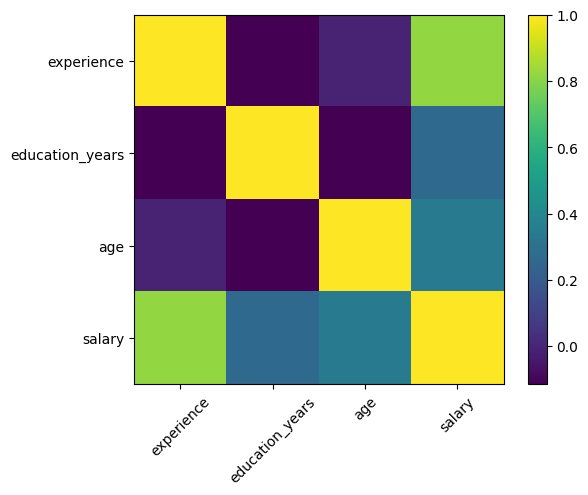

In [12]:
corr = data.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show

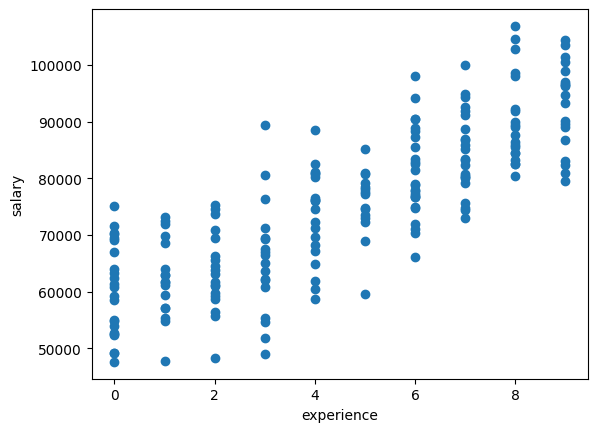

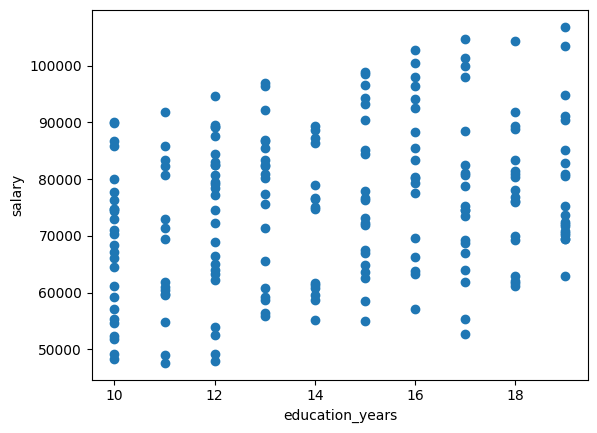

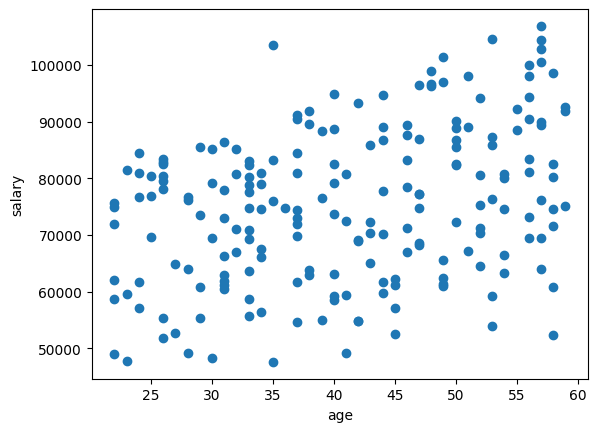

In [13]:
features = ["experience", "education_years", "age"]

for col in features:
  plt.figure()
  plt.scatter(data[col], data["salary"])
  plt.xlabel(col)
  plt.ylabel("salary")
  plt.show()

In [14]:
x = data[["experience", "education_years", "age"]]
y = data["salary"]

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [16]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [17]:
print(model.coef_)
print(model.intercept_)



[4051.32422733 1930.77264031  497.35334712]
8713.738714952677


In [18]:
y_pred = model.predict(x_test)

In [19]:
8713+6*4051+15*1930+22*497

72903

In [20]:
mse= mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mse,rmse, r2)

6941242.686695042 2634.6238226158666 0.9655519489971883


In [22]:
new_data = pd.DataFrame({
    "experience": [5],
    "education_years": [16],
    "age": [30]
})

print(model.predict(new_data))

[74783.3225103]
